In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/dataset_08_email_priority_classification.csv")

In [ ]:
df.head()

,sender_frequency,keyword_score,thread_length,response_deadline_hours,attachment_count,previous_priority_rate,target
0,4,29.17,4,2.79,5,58.60,1
1,2,70.15,3,18.37,1,83.35,0
2,1,36.13,5,11.05,1,71.34,1
3,6,38.22,2,1.00,3,52.27,1
4,5,20.93,1,16.53,1,43.43,0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 7


In [ ]:
print(df.columns.tolist())

['sender_frequency', 'keyword_score', 'thread_length', 'response_deadline_hours', 'attachment_count', 'previous_priority_rate', 'target']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sender_frequency         1000 non-null   int64  
 1   keyword_score            1000 non-null   float64
 2   thread_length            1000 non-null   int64  
 3   response_deadline_hours  1000 non-null   float64
 4   attachment_count         1000 non-null   int64  
 5   previous_priority_rate   1000 non-null   float64
 6   target                   1000 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 54.8 KB


In [ ]:
df.describe()

,sender_frequency,keyword_score,thread_length,response_deadline_hours,attachment_count,previous_priority_rate,target
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,3.007000,49.834610,2.96300,10.606920,2.951000,49.636530,0.50000
std,1.795041,19.239085,1.70779,6.973134,1.771931,19.139961,0.50025
min,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.00000
25%,2.000000,36.877500,2.00000,4.907500,2.000000,36.677500,0.00000
50%,3.000000,49.255000,3.00000,9.950000,3.000000,49.505000,0.50000
75%,4.000000,62.517500,4.00000,15.242500,4.000000,62.400000,1.00000
max,10.000000,100.000000,10.00000,37.370000,10.000000,100.000000,1.00000


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nMissing Percentage")
print(df.isnull().sum()*100)

Missing Values:
sender_frequency           0
keyword_score              0
thread_length              0
response_deadline_hours    0
attachment_count           0
previous_priority_rate     0
target                     0
dtype: int64

Missing Percentage
sender_frequency           0
keyword_score              0
thread_length              0
response_deadline_hours    0
attachment_count           0
previous_priority_rate     0
target                     0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

print("\nDuplicate Rows")
print(df[df.duplicated()])

Duplicate Rows: 0

Duplicate Rows
Empty DataFrame
Columns: [sender_frequency, keyword_score, thread_length, response_deadline_hours, attachment_count, previous_priority_rate, target]
Index: []


In [ ]:
print(df[df["sender_frequency"] < 0])

Empty DataFrame
Columns: [sender_frequency, keyword_score, thread_length, response_deadline_hours, attachment_count, previous_priority_rate, target]
Index: []


In [ ]:
print(df[df["keyword_score"] < 0])

Empty DataFrame
Columns: [sender_frequency, keyword_score, thread_length, response_deadline_hours, attachment_count, previous_priority_rate, target]
Index: []


In [ ]:
print(df[df["thread_length"] < 0])

Empty DataFrame
Columns: [sender_frequency, keyword_score, thread_length, response_deadline_hours, attachment_count, previous_priority_rate, target]
Index: []


In [ ]:
print(df[df["response_deadline_hours"] < 0])

Empty DataFrame
Columns: [sender_frequency, keyword_score, thread_length, response_deadline_hours, attachment_count, previous_priority_rate, target]
Index: []


In [ ]:
print(df[df["attachment_count"] < 0])

Empty DataFrame
Columns: [sender_frequency, keyword_score, thread_length, response_deadline_hours, attachment_count, previous_priority_rate, target]
Index: []


In [ ]:
print(df[df["previous_priority_rate"] < 0])

Empty DataFrame
Columns: [sender_frequency, keyword_score, thread_length, response_deadline_hours, attachment_count, previous_priority_rate, target]
Index: []


In [ ]:
print(df[df["target"] < 0])

Empty DataFrame
Columns: [sender_frequency, keyword_score, thread_length, response_deadline_hours, attachment_count, previous_priority_rate, target]
Index: []


In [ ]:
Q1 = df["target"].quantile(0.25)
Q3 = df["target"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

target_outliers = df[
    (df["target"] < lower_bound) |
    (df["target"] > upper_bound)
]

print("Number of Target Outliers:", len(target_outliers))

Number of Target Outliers: 0


In [ ]:
target_counts = df["target"].value_counts().sort_index()

print("Target Value Counts:")
print(target_counts)

print("\nPecentage of Target Values:")
print(df["target"].value_counts(normalize=True).sort_index() * 100)

Target Value Counts:
target
0    500
1    500
Name: count, dtype: int64

Pecentage of Target Values:
target
0    50.0
1    50.0
Name: proportion, dtype: float64


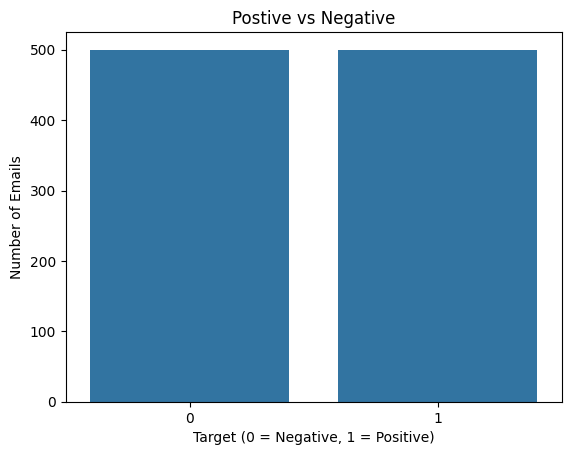

In [ ]:
sns.countplot(x="target", data=df)

plt.title("Postive vs Negative")

plt.xlabel("Target (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Emails")

plt.show()

In [ ]:
features = [
    "sender_frequency",
    "keyword_score",
    "thread_length",
    "response_deadline_hours",
    "attachment_count",
    "previous_priority_rate"
]

print("Feature Ranges:\n")

for column in features:
  print(f"{column}: Min = {df[column].min()}, Max = {df[column].max()}")

Feature Ranges:

sender_frequency: Min = 0, Max = 10
keyword_score: Min = 0.0, Max = 100.0
thread_length: Min = 0, Max = 10
response_deadline_hours: Min = 1.0, Max = 37.37
attachment_count: Min = 0, Max = 10
previous_priority_rate: Min = 0.0, Max = 100.0


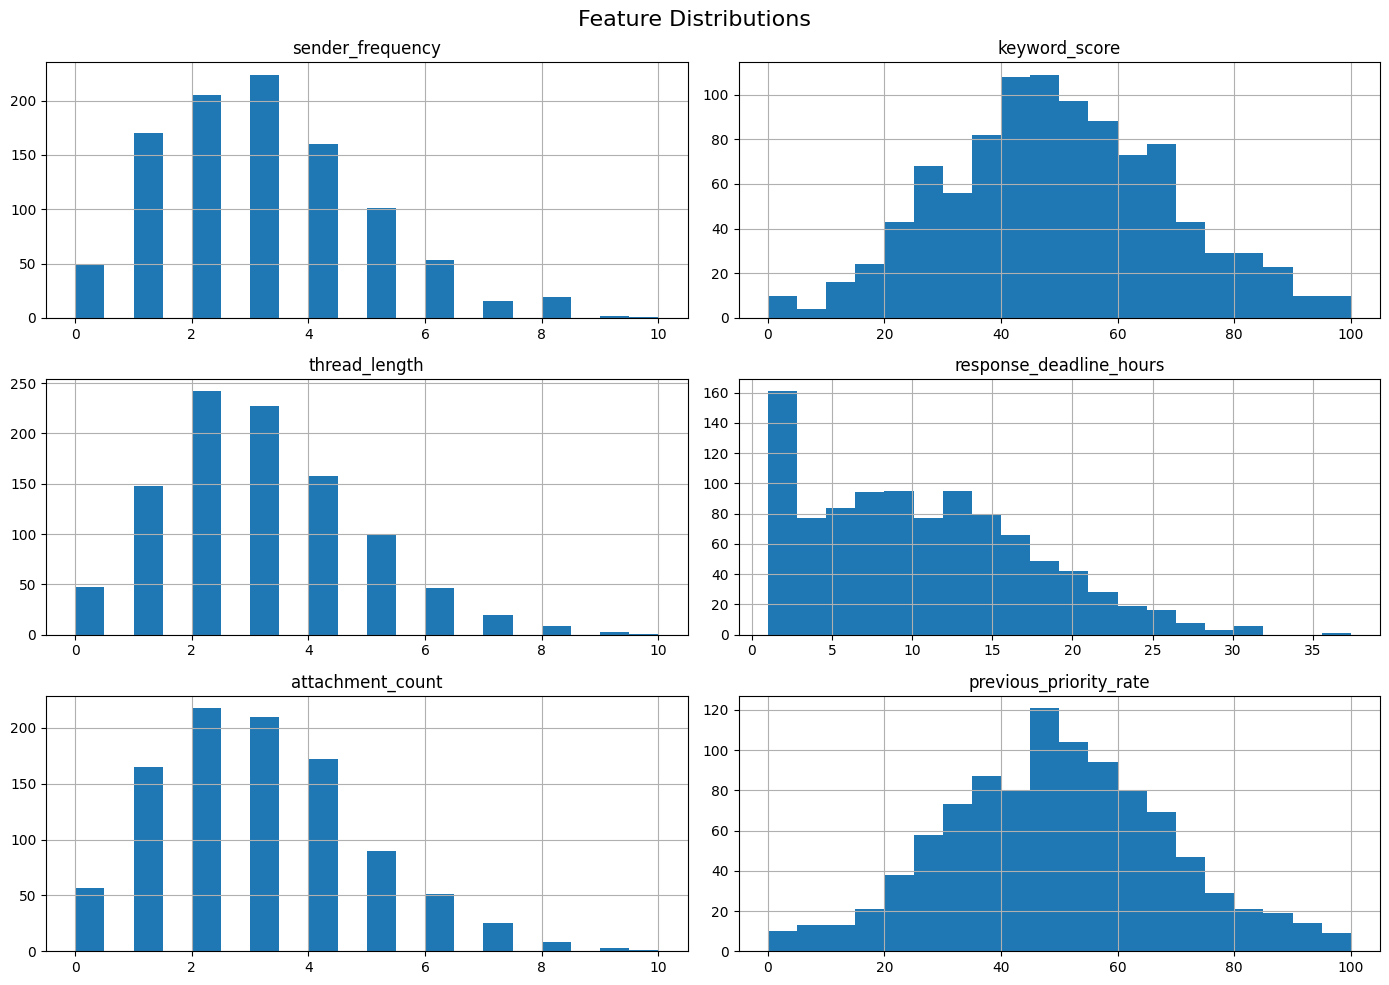

In [ ]:
df[features].hist(bins=20, figsize=(14, 10))

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
correlation = df.corr(numeric_only=True)

print(correlation)

                         sender_frequency  keyword_score  thread_length  \
sender_frequency                 1.000000       0.035731      -0.042365   
keyword_score                    0.035731       1.000000       0.011860   
thread_length                   -0.042365       0.011860       1.000000   
response_deadline_hours         -0.032168       0.023499      -0.012899   
attachment_count                 0.038818       0.051344      -0.009531   
previous_priority_rate          -0.013252       0.035706      -0.001125   
target                           0.221275      -0.173910       0.211490   

                         response_deadline_hours  attachment_count  \
sender_frequency                       -0.032168          0.038818   
keyword_score                           0.023499          0.051344   
thread_length                          -0.012899         -0.009531   
response_deadline_hours                 1.000000          0.037923   
attachment_count                        0.037923 

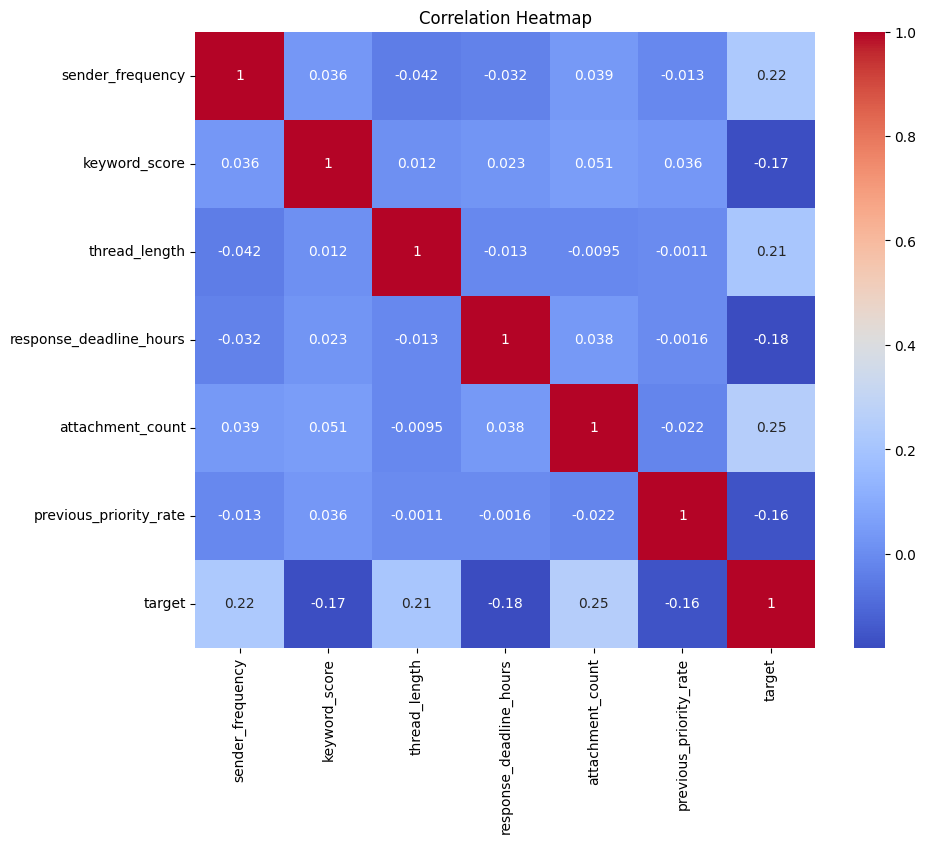

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
X = df[
    [
        "sender_frequency",
        "keyword_score",
        "thread_length",
        "response_deadline_hours",
        "attachment_count",
        "previous_priority_rate"
    ]
]

y = df["target"]

print("X")
print(X.head())

print("\nY")
print(y.head())

X
   sender_frequency  keyword_score  thread_length  response_deadline_hours  \
0                 4          29.17              4                     2.79   
1                 2          70.15              3                    18.37   
2                 1          36.13              5                    11.05   
3                 6          38.22              2                     1.00   
4                 5          20.93              1                    16.53   

   attachment_count  previous_priority_rate  
0                 5                   58.60  
1                 1                   83.35  
2                 1                   71.34  
3                 3                   52.27  
4                 1                   43.43  

Y
0    1
1    0
2    1
3    1
4    0
Name: target, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 6)
X_test: (200, 6)
y_train: (800,)
y_test: (200,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[ 1.7209069   0.49699359 -0.57025527 -0.49597913  0.59597967 -0.94707178]
 [-0.54158368  1.98458458 -0.57025527 -0.58616145  1.155585   -0.55819828]
 [ 0.58966161 -0.16659634  0.00941972  0.08729685 -0.52323098  0.5920054 ]
 [ 0.02403896  0.5194616  -0.57025527 -0.06834038 -0.52323098 -0.81317207]
 [-1.10720633 -0.0626165   0.00941972 -0.8508902  -0.52323098 -0.32938881]]


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:10])

[1 0 0 0 0 1 1 1 1 0]


In [ ]:
y_probability = model.predict_proba(X_test_scaled)

print(y_probability[:10])

[[0.29903034 0.70096966]
 [0.68644615 0.31355385]
 [0.68794856 0.31205144]
 [0.69082118 0.30917882]
 [0.65196107 0.34803893]
 [0.06750583 0.93249417]
 [0.18920856 0.81079144]
 [0.25001607 0.74998393]
 [0.48770986 0.51229014]
 [0.88947668 0.11052332]]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.66


In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[62 38]
 [30 70]]


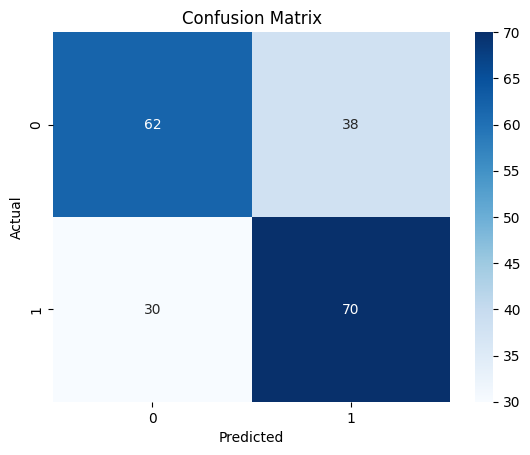

In [ ]:
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision Score:", precision)

Precision Score: 0.6481481481481481


In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall Score:", recall)

Recall Score: 0.7


In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.6730769230769231


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_probability[:, 1])

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.7343000000000001


In [ ]:
from sklearn.metrics import classification_report

classification_rep = classification_report(y_test, y_pred, target_names=["Negative","Positive"], zero_division=0)

print("Classification Report:")
print(classification_rep)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.62      0.65       100
    Positive       0.65      0.70      0.67       100

    accuracy                           0.66       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.66      0.66      0.66       200



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability[:, 1])

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

Accuracy: 0.66
Precision: 0.6481481481481481
Recall: 0.7
F1 Score: 0.6730769230769231
ROC AUC Score: 0.7343000000000001


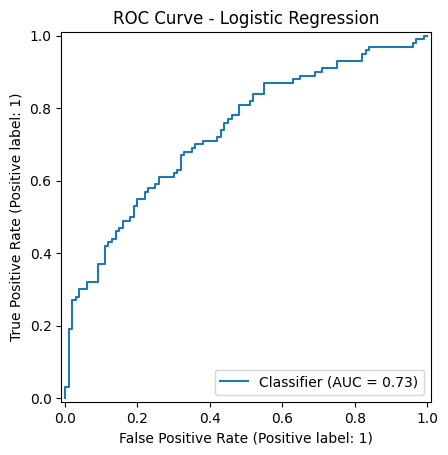

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_probability[:, 1])

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [ ]:
coefficients = model.coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients,
    "Odds Ratio": np.exp(coefficients)
})

coefficient_df = coefficient_df.sort_values(by="Coefficient", ascending = False)

display(coefficient_df)

,Feature,Coefficient,Odds Ratio
4,attachment_count,0.703534,2.020881
0,sender_frequency,0.670496,1.955207
2,thread_length,0.642721,1.901648
5,previous_priority_rate,-0.371861,0.689450
1,keyword_score,-0.416070,0.659634
3,response_deadline_hours,-0.494929,0.609614


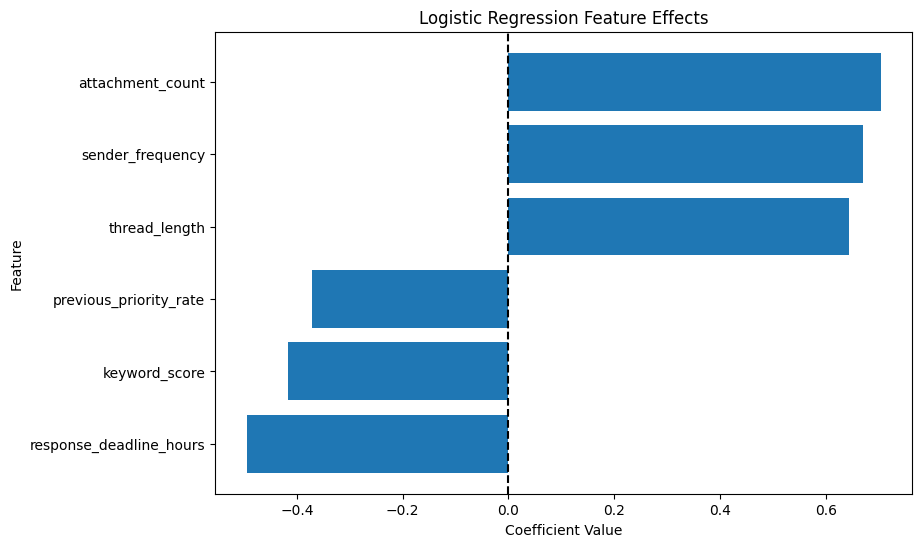

In [ ]:
plot_df = coefficient_df.sort_values("Coefficient")

plt.figure(figsize=(9, 6))

plt.barh(y=plot_df["Feature"], width=plot_df["Coefficient"])

plt.axvline(x=0, color="black", linestyle="--")

plt.title("Logistic Regression Feature Effects")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

In [ ]:
importance_df = coefficient_df.copy()

importance_df["Absolute Coefficient"] = (importance_df["Coefficient"].abs())

importance_df = importance_df.sort_values(by="Absolute Coefficient", ascending=False)

display(importance_df)

,Feature,Coefficient,Odds Ratio,Absolute Coefficient
4,attachment_count,0.703534,2.020881,0.703534
0,sender_frequency,0.670496,1.955207,0.670496
2,thread_length,0.642721,1.901648,0.642721
3,response_deadline_hours,-0.494929,0.609614,0.494929
1,keyword_score,-0.416070,0.659634,0.416070
5,previous_priority_rate,-0.371861,0.689450,0.371861


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC AUC Score": [roc_auc]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,Logistic Regression,0.66,0.648148,0.7,0.673077,0.7343


In [ ]:
tn, fp, fn, tp = confusion_matrix.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

print("\nFalse Positive Rate:", fp / (fp + tn))
print("False Negative Rate:", fn / (fn + tp))

True Negatives: 62
False Positives: 38
False Negatives: 30
True Positives: 70

False Positive Rate: 0.38
False Negative Rate: 0.3


## Limitations

1. The dataset contains only 1,000 observations, so the model may not generalize to a much larger and more diverse real-world email population.

2. The available predictors are numerical summary features rather than the actual email text, subject, sender identity, or semantic content.

3. Logistic Regression assumes a linear relationship between the predictors and the log-odds of the target. More complex relationships may not be captured.

4. The test-set recall is 70%, meaning that 30% of the actual high-priority emails in the test set were missed by the model.

5. The dataset is perfectly balanced, whereas real-world email priority data may be considerably imbalanced.

6. The observed coefficient directions are specific to this dataset and should not automatically be interpreted as causal relationships.

7. A single train/test split provides only one estimate of generalization performance. Cross-validation would provide a more robust estimate.

8. The default classification threshold of 0.5 may not be optimal for an operational email-priority system. The threshold should ideally be selected according to the relative cost of missed high-priority emails and unnecessary priority notifications.


## Possible Improvements

Future improvements could include:

* Collecting a larger and more representative email dataset.
* Adding text-based features from email subject and body.
* Using TF-IDF or modern text embeddings for semantic information.
* Applying cross-validation to obtain more reliable performance estimates.
* Optimizing the classification threshold based on the business cost of false positives and false negatives.
* Monitoring model performance after deployment.
* Evaluating more complex models only if they provide a meaningful improvement over the Logistic Regression baseline.
* Periodically retraining the model as email patterns and priority behavior change.


## Final Conclusion

The Email Priority Classification project successfully implemented a binary Logistic Regression classifier using six numerical predictors.

The dataset contained 1,000 observations and was free from missing values and duplicate records. The target classes were perfectly balanced, with 500 normal/low-priority emails and 500 high-priority emails.

An 80:20 stratified train-test split was used with **random_state=42**. Numerical preprocessing was implemented inside a Pipeline using median imputation and StandardScaler, preventing preprocessing leakage between the training and testing datasets.

The Logistic Regression model achieved 66.00% accuracy, 64.81% precision, 70.00% recall, 67.31% F1-score, and 73.43% ROC-AUC on the test set.

The confusion matrix contained 62 true negatives, 38 false positives, 30 false negatives, and 70 true positives. The model therefore identified 70% of the actual high-priority emails in the test set but missed 30%. Since missing a high-priority email can be more costly than incorrectly prioritizing a normal email, recall should be an important consideration for practical deployment.

Coefficient analysis showed that **attachment_count**, **sender_frequency**, and **thread_length** had the strongest positive associations with the predicted **high-priority class**, while **response_deadline_hours**, **keyword_score**, and **previous_priority_rate** had negative coefficients in this dataset.

Overall, Logistic Regression provides a useful, interpretable baseline for this email-priority classification problem. However, the moderate performance indicates that additional data, richer features, cross-validation, and business-oriented threshold optimization would be valuable before considering real-world deployment.


In [ ]:
sender_frequency = float(input("Enter Sender Frequency: "))
keyword_score = float(input("Enter Keyword Score: "))
thread_length = float(input("Enter Thread Length: "))
response_deadline_hours = float(input("Enter Response Deadline Hours: "))
attachment_count = float(input("Enter Attachment Count: "))
previous_priority_rate = float(input("Enter Previous Priority Rate: "))

Enter Sender Frequency: 2
Enter Keyword Score: 70.15
Enter Thread Length: 3
Enter Response Deadline Hours: 18.37
Enter Attachment Count: 1
Enter Previous Priority Rate: 83.35


In [ ]:
usr_data = pd.DataFrame([
    {
        "sender_frequency": sender_frequency,
        "keyword_score": keyword_score,
        "thread_length": thread_length,
        "response_deadline_hours": response_deadline_hours,
        "attachment_count": attachment_count,
        "previous_priority_rate": previous_priority_rate
    }
])

print(usr_data)

   sender_frequency  keyword_score  thread_length  response_deadline_hours  \
0               2.0          70.15            3.0                    18.37   

   attachment_count  previous_priority_rate  
0               1.0                   83.35  


In [ ]:
usr_data_scaled = scaler.transform(usr_data)

print(usr_data_scaled)

[[-0.54158368  1.05608118  0.00941972  1.14039363 -1.08283631  1.72425317]]


In [ ]:
prediction = model.predict(usr_data_scaled)
print(prediction)

probability = model.predict_proba(usr_data_scaled)
print(probability)

if prediction[0] == 1:
    print("Prediction: Positive")
else:
    print("Prediction: Negative")

[0]
[[0.93984058 0.06015942]]
Prediction: Negative
